# Figure — county-level flow-disruption maps (Helene × Milton)

**Layout:** 2 rows (hurricanes) × 3 columns (flow types: within / inflow / outflow).

**Metric mapped per column**
- *Within* → `largest_drop` (%) — deepest within-county mobility drop
- *Inflow* → `largest_drop` (%) — deepest inflow drop
- *Outflow* → `largest_increase` (%) — peak outflow surge (evacuation), per methodology §5.2

**Colour:** one consistent diverging palette (`RdBu`, symmetric, centred at 0), shared across both
hurricanes within each column → **red = below baseline (drop), blue = above baseline (surge)**.

**Spatial units**
- *Helene*: cluster-level — each county inherits its NCHS cluster's value (271 counties → 38 clusters).
- *Milton*: county-level — `unit_id` is the county GEOID (21 counties).

**Affected-region cutoff:** both hurricanes use the **50-mile** local-level analysis (canonical).
Helene at 50 mi excludes the Appalachian / Asheville flooding region; to include it, set the Helene
`dir` to `helene_100mi` in the config cell (same `metrics_*` / `county_cluster_assignments.csv` schema).

**Data sources** — county geometry & storm tracks live in the sibling `hurricane_oct/data/`
(TIGER 2023 counties; storm-track point shapefiles), projected to EPSG:5070. Flow metrics:
`results/local_level/{helene,milton}/metrics_{within,inflow,outflow}.csv`.

**Environment:** requires the `geo` conda env (`geopandas`, `shapely`).
Output: `results/npj_figures/figure_flow_maps.{png,pdf}`.


In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from shapely.geometry import LineString

# --- paths ---
ROOT = "/Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category"
HO   = "/Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/hurricane_oct"
COUNTY_SHP = f"{HO}/data/county_geo/tl_2023_us_county/tl_2023_us_county.shp"
TRACK_SHP  = {"Helene": f"{HO}/data/storm_track/helene_storm_track.shp",
              "Milton": f"{HO}/data/storm_track/milton_storm_track.shp"}
LL  = f"{ROOT}/results/local_level"
OUT = f"{ROOT}/results/npj_figures"

# --- config: affected-region cutoff per hurricane ---
# 50 mi = canonical local-level analysis. For Helene's Appalachian footprint use dir="helene_100mi".
HURR = {"Helene": dict(dir="helene", level="cluster", landfall="2024-09-26"),
        "Milton": dict(dir="milton", level="county",  landfall="2024-10-09")}

# (key, metric column, colourbar label)
FLOWS = [("within",  "largest_drop",     "Within: largest drop (%)"),
         ("inflow",  "largest_drop",     "Inflow: largest drop (%)"),
         ("outflow", "largest_increase", "Outflow: largest increase (%)")]

FIG_W, FIG_H = 7.2, 5.4          # 183 mm double-column, print size
OUTNAME = "figure_flow_maps"

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7, 'pdf.fonttype': 42, 'ps.fonttype': 42, 'savefig.dpi': 300,
})

In [2]:
# --- geometry, states, storm tracks (EPSG:5070) ---
counties = gpd.read_file(COUNTY_SHP)[["GEOID", "STATEFP", "geometry"]].copy()
counties["GEOID"] = counties["GEOID"].astype(int)
counties = counties.to_crs(epsg=5070)
states = counties.dissolve(by="STATEFP")[["geometry"]]

def load_track(p):
    t = gpd.read_file(p)
    line = LineString(t.geometry.tolist()) if (t.geom_type == "Point").all() else t.unary_union
    return gpd.GeoDataFrame(geometry=[line], crs=t.crs).to_crs(epsg=5070)

tracks = {h: load_track(p) for h, p in TRACK_SHP.items()}

In [3]:
# --- assemble one choropleth layer per (hurricane, flow) ---
def build_layer(hur, flow, col):
    cfg = HURR[hur]
    m = pd.read_csv(f"{LL}/{cfg['dir']}/metrics_{flow}.csv")[["unit_id", col]]
    m.columns = ["unit_id", "value"]
    if cfg["level"] == "county":                       # unit_id IS the county GEOID
        m = m.rename(columns={"unit_id": "GEOID"})
        m["GEOID"] = m["GEOID"].astype(int)
        return counties.merge(m[["GEOID", "value"]], on="GEOID", how="right")
    # cluster level: spread each cluster's value onto its member counties
    ca = pd.read_csv(f"{LL}/{cfg['dir']}/county_cluster_assignments.csv")[["GEOID", "cluster"]]
    ca["GEOID"] = ca["GEOID"].astype(int)
    d = ca.merge(m.rename(columns={"unit_id": "cluster"}), on="cluster", how="left")
    return counties.merge(d[["GEOID", "value"]], on="GEOID", how="right")

layers = {}
for h in HURR:
    for flow, col, _ in FLOWS:
        g = build_layer(h, flow, col)
        layers[(h, flow)] = g
        print(f"{h:7s} {flow:8s} n={len(g):3d} valid={g['value'].notna().sum():3d}"
              f" range=[{g['value'].min():6.1f},{g['value'].max():6.1f}]")

# per-column symmetric diverging norm, shared across both hurricanes
norms = {}
for flow, col, _ in FLOWS:
    vals = pd.concat([layers[(h, flow)]["value"] for h in HURR]).dropna()
    vlim = float(np.nanmax(np.abs(vals)))
    norms[flow] = TwoSlopeNorm(vmin=-vlim, vcenter=0.0, vmax=vlim)
CMAP = "RdBu"   # red = below baseline (drop), blue = above baseline (surge)

Helene  within   n=271 valid=271 range=[ -29.6,  -3.6]
Helene  inflow   n=271 valid=271 range=[ -42.2,  13.2]
Helene  outflow  n=271 valid=271 range=[ -31.4, 105.7]
Milton  within   n= 21 valid= 21 range=[ -46.3, -19.1]
Milton  inflow   n= 21 valid= 21 range=[ -68.1,  -9.4]
Milton  outflow  n= 21 valid= 21 range=[ -50.7, 119.2]


saved -> /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure_flow_maps.png / .pdf


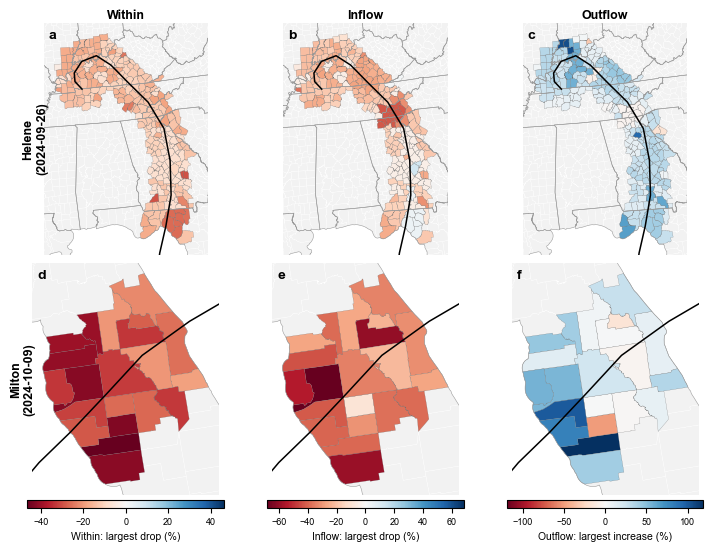

In [4]:
# --- 2x3 map grid ---
fig, axes = plt.subplots(2, 3, figsize=(FIG_W, FIG_H), constrained_layout=True)
panel = iter("abcdef")
for r, h in enumerate(HURR):
    for c, (flow, col, _) in enumerate(FLOWS):
        ax = axes[r, c]
        g = layers[(h, flow)]
        minx, miny, maxx, maxy = g.total_bounds
        pad = 0.05 * max(maxx - minx, maxy - miny)
        x0, y0, x1, y1 = minx - pad, miny - pad, maxx + pad, maxy + pad
        counties.cx[x0:x1, y0:y1].plot(ax=ax, facecolor="#f2f2f2",
                                       edgecolor="white", linewidth=0.25)
        states.cx[x0:x1, y0:y1].boundary.plot(ax=ax, color="#9a9a9a", linewidth=0.4)
        g.plot(ax=ax, column="value", cmap=CMAP, norm=norms[flow],
               edgecolor="#666666", linewidth=0.15,
               missing_kwds={"color": "#dddddd", "edgecolor": "#999999", "linewidth": 0.15})
        tracks[h].plot(ax=ax, color="black", linewidth=1.1)
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
        ax.set_aspect("equal"); ax.set_axis_off()
        ax.text(0.03, 0.97, next(panel), transform=ax.transAxes,
                va="top", ha="left", fontweight="bold", fontsize=10)
        if r == 0:
            ax.set_title(flow.capitalize(), fontweight="bold", fontsize=9, pad=3)
        if c == 0:
            ax.text(-0.05, 0.5, f"{h}\n({HURR[h]['landfall']})", transform=ax.transAxes,
                    rotation=90, va="center", ha="center", fontweight="bold", fontsize=9)

for c, (flow, col, label) in enumerate(FLOWS):
    sm = mpl.cm.ScalarMappable(norm=norms[flow], cmap=CMAP); sm.set_array([])
    cb = fig.colorbar(sm, ax=axes[:, c], location="bottom", shrink=0.85, aspect=26, pad=0.01)
    cb.set_label(label, fontsize=7.5)
    cb.ax.tick_params(labelsize=6.5)

os.makedirs(OUT, exist_ok=True)
for ext in ("png", "pdf"):
    fig.savefig(f"{OUT}/{OUTNAME}.{ext}", dpi=400, bbox_inches="tight")
print("saved ->", f"{OUT}/{OUTNAME}.png / .pdf")
plt.show()